# SPRAG — Exploratory Data Analysis

EDA on the cleaned corpus produced by `app/sprag/cleaning.py`, which runs on the raw corpus from `app/sprag/loader.py`, profiled by `app/sprag/profiling.py`.

Findings so far: 127 duplicate `(QuestionID, StudentAnswer)` rows dropped, 3 rows with encoding artifacts fixed, 279 code-eliciting rows dropped (questions verified by text pattern, not the unreliable `QuestionType` label).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('../data/cleaned/sprag_cleaned.parquet')
df.shape

(2522, 6)

## Overview

In [2]:
df.dtypes

id                  str
QuestionID          str
StudentAnswer       str
QuestionText        str
QuestionType        str
Reference Answer    str
dtype: object

## Confirm the code-filter actually worked

Cleaning dropped rows whose question matched the verified "write a function/script/program" pattern - spot-check that none slipped through.

In [3]:
remaining_code_like = df['QuestionText'].str.contains(
    r'write\s+an?\s+(?:\w+\s+)?(?:function|script|program)', case=False, regex=True
)
remaining_code_like.sum()

np.int64(0)

## Answer length

Same baseline purpose as Mohler's - confirms this is genuinely short-answer data, and gives a length reference to compare AI-generated answers against later, so a detector can't just learn to key off length.

In [4]:
word_counts = df['StudentAnswer'].str.split().str.len()
word_counts.describe()

count    2522.000000
mean       14.051150
std        13.367868
min         1.000000
25%         6.000000
50%        11.000000
75%        18.000000
max       267.000000
Name: StudentAnswer, dtype: float64

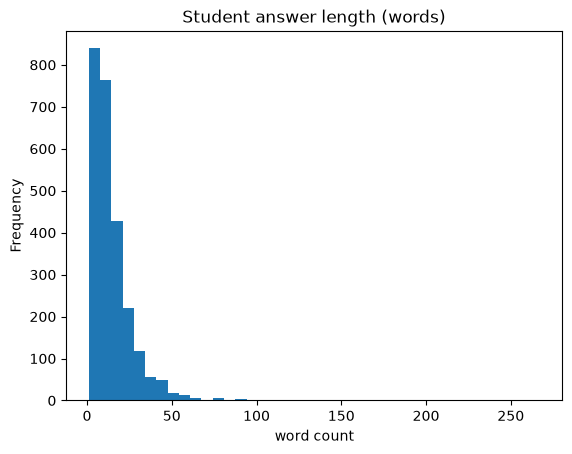

In [5]:
word_counts.plot(kind='hist', bins=40, title='Student answer length (words)')
plt.xlabel('word count')
plt.show()

## Questions per type (post-cleaning)

Sanity check on what's left after dropping code-eliciting rows - confirms the remaining mix is genuinely prose-based.

In [6]:
df['QuestionType'].value_counts()

QuestionType
Explain       970
Define        608
Remember      417
Difference    362
Apply          80
Name: count, dtype: int64